## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split

In [2]:
real_or_simulated = 'all' #simulated / real / all
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
remove_outliers = False

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
if remove_outliers:
    outliers = 'outliers_removed'
else:
    outliers = 'outliers_present'

In [3]:
outliers_indices = {
    'simulated': list(range(1035, 1050)) + list(range(1020, 1035)),
    'real': list(range(2370, 2385))
                    }

## Loading the data

In [4]:
data_path = '../data/DANE.xlsx'

In [5]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

In [6]:
inds_df = inds_df.reset_index(drop=False)

### Creating labels column

In [7]:
inds_df['Label'] = np.repeat(list(range(1, int(inds_df.shape[0]/15)+1)), 15)

## Preprocessing

### Removing some data

1. Let's remove rows with missing values.

In [8]:
(inds_df.shape[0] - inds_df.dropna().shape[0])/inds_df.shape[0]

0.030303030303030304

In [9]:
inds_df.dropna(inplace=True)

In [10]:
inds_df.shape

(3840, 33)

2. Let's keep only columns that we need.

In [11]:
inds_colnames = [col for col in inds_df.columns if col != 'nazwa próbki'and
                                                    col != 'seria' and
                                                    col != 'Fe' and 
                                                    col != 'Label']
#no iron because it's a reference element

### Creating features and labels matrices

In [12]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


/home/basia/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:88: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [13]:
X = np.array(inds_df[inds_colnames].values)
y = np.array(pd.get_dummies(inds_df['Label']))

if remove_outliers:
    if real_or_simulated == 'real':
        indices_to_remove = outliers_indices['real']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'simulated':
        indices_to_remove = outliers_indices['simulated']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'all':
        indices_to_remove = outliers_indices['simulated'] + \
                            [ind + 1425 for ind in outliers_indices['real']]
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

In [14]:
X = torch.Tensor(X).to(device)
y = torch.Tensor(y).to(device)

In [15]:
out_features = y.shape[1]

### Train test split, datasets, dataloaders

15 slices from the same sample should either all go to train or all go to test.

In [16]:
if keep_sample_together:
    indices = list(range(int(X.shape[0]/15)))
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    ind_train_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_train]
    ind_train_all = [x for l in ind_train_all for x in l]
    ind_val_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_val]
    ind_val_all = [x for l in ind_val_all for x in l]
    ind_test_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_test]
    ind_test_all = [x for l in ind_test_all for x in l]

else:
    indices = list(range(int(X.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)

In [17]:
partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}

In [18]:
X_train = X[partition['train']]
y_train = y[partition['train']]

X_val = X[partition['val']]
y_val = y[partition['val']]

X_test = X[partition['test']]
y_test = y[partition['test']]

In [19]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [20]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [21]:
# loader = DataLoader(list(zip(X_train, y_train)), shuffle=True, batch_size=100)
# test_loader = DataLoader(list(zip(X_test, y_test)))

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=True)

## Building neural network

In [22]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(29, 50),
        #nn.Dropout(),
        nn.ReLU(),
        nn.Linear(50, 50),
        nn.ReLU(),
        nn.Linear(50, out_features))
    def forward(self, x):
        return self.seq(x)

## Training

In [23]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=29, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=256, bias=True)
  )
)


In [24]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

In [25]:
EPOCHS = 2000
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 157.47086932261786 test 134.04196155515578
EPOCH 2:
LOSS train 128.04624581336975 test 113.84626628815506
EPOCH 3:
LOSS train 108.89248621463776 test 99.92157513640511
EPOCH 4:
LOSS train 95.00415968894958 test 88.51531109345763
EPOCH 5:
LOSS train 88.02814245223999 test 77.77651277395954
EPOCH 6:
LOSS train 72.66657503445943 test 68.96611765062454
EPOCH 7:
LOSS train 66.32605985800426 test 60.87199603734189
EPOCH 8:
LOSS train 55.25478688875834 test 53.7795464393663
EPOCH 9:
LOSS train 47.40639636913935 test 47.714713701249735
EPOCH 10:
LOSS train 40.91486072540283 test 41.41649432118262
EPOCH 11:
LOSS train 38.804019371668495 test 35.60696561988067
EPOCH 12:
LOSS train 27.278968175252277 test 29.62454303967564
EPOCH 13:
LOSS train 22.107507983843487 test 23.254939805068734
EPOCH 14:
LOSS train 17.29515637954076 test 21.10424968744677
EPOCH 15:
LOSS train 41.168739795684814 test 19.295460450909854
EPOCH 16:
LOSS train 13.915099521478018 test 16.961847817147937
EPOC

LOSS train 3.2636813521385193 test 4.075635654028239
EPOCH 133:
LOSS train 3.2892918785413108 test 3.5228109296449523
EPOCH 134:
LOSS train 3.2417536079883575 test 3.4291058070335727
EPOCH 135:
LOSS train 3.275056858857473 test 3.400690448789844
EPOCH 136:
LOSS train 3.187600831190745 test 3.35681879629577
EPOCH 137:
LOSS train 3.145547995964686 test 3.3352802702211313
EPOCH 138:
LOSS train 3.2233392099539437 test 3.3982032174687706
EPOCH 139:
LOSS train 3.2215306560198465 test 3.485553902631024
EPOCH 140:
LOSS train 3.138773043950399 test 3.4604910643011326
EPOCH 141:
LOSS train 3.1950352787971497 test 3.5133037030819794
EPOCH 142:
LOSS train 3.113569974899292 test 3.598155767589123
EPOCH 143:
LOSS train 3.1914901236693063 test 3.5344336491536734
EPOCH 144:
LOSS train 3.1344804068406424 test 3.521968389995603
EPOCH 145:
LOSS train 3.143320689598719 test 3.623874484198037
EPOCH 146:
LOSS train 3.1126802961031594 test 3.640778005603528
EPOCH 147:
LOSS train 3.0926740566889444 test 3.659

LOSS train 2.7388119449218116 test 2.639455513560134
EPOCH 262:
LOSS train 2.151136487722397 test 2.4350735007081274
EPOCH 263:
LOSS train 2.08380156258742 test 2.4313469153933704
EPOCH 264:
LOSS train 2.0986803621053696 test 2.457573399821522
EPOCH 265:
LOSS train 2.081083118915558 test 2.493040443788114
EPOCH 266:
LOSS train 2.064106523990631 test 2.5133994918329554
EPOCH 267:
LOSS train 2.041575481494268 test 2.491435426953369
EPOCH 268:
LOSS train 2.050812433163325 test 2.525425075590538
EPOCH 269:
LOSS train 2.076943283279737 test 2.5650403248404325
EPOCH 270:
LOSS train 2.049572631716728 test 2.548553708176767
EPOCH 271:
LOSS train 2.0504771719376245 test 2.5395387703194765
EPOCH 272:
LOSS train 2.0043710519870124 test 2.565825153190968
EPOCH 273:
LOSS train 2.0019246488809586 test 2.6223298187768584
EPOCH 274:
LOSS train 2.16304549574852 test 2.680856749307786
EPOCH 275:
LOSS train 2.1299153914054236 test 2.6330706319851873
EPOCH 276:
LOSS train 2.0021422455708184 test 2.6460025

LOSS train 1.3866318315267563 test 1.9100976179803026
EPOCH 390:
LOSS train 1.361091434955597 test 1.9048278801152876
EPOCH 391:
LOSS train 1.3571904723842938 test 1.9227705802147963
EPOCH 392:
LOSS train 1.3624420339862506 test 1.9400566178436904
EPOCH 393:
LOSS train 1.3569009428222973 test 1.9761613263025364
EPOCH 394:
LOSS train 1.356227179368337 test 1.9530407222261832
EPOCH 395:
LOSS train 1.3725283443927765 test 1.9784207709963162
EPOCH 396:
LOSS train 1.3667405545711517 test 2.0379237316989536
EPOCH 397:
LOSS train 1.3378393004337947 test 2.0381266687284842
EPOCH 398:
LOSS train 1.3754472335179646 test 2.01231447508701
EPOCH 399:
LOSS train 1.376114934682846 test 2.0427154607203706
EPOCH 400:
LOSS train 1.3447215060393016 test 2.056457255752053
EPOCH 401:
LOSS train 1.38838026424249 test 2.0623211876352365
EPOCH 402:
LOSS train 1.335597554842631 test 2.069918229607094
EPOCH 403:
LOSS train 1.3675030966599782 test 2.0813689620459463
EPOCH 404:
LOSS train 1.3469210714101791 test 

LOSS train 0.9473009978731474 test 1.502658870815231
EPOCH 519:
LOSS train 0.9784987991054853 test 1.522482125908578
EPOCH 520:
LOSS train 0.9496472328901291 test 1.5203754717185494
EPOCH 521:
LOSS train 0.975792462627093 test 1.6449972655636298
EPOCH 522:
LOSS train 0.9979492202401161 test 1.6498262032139779
EPOCH 523:
LOSS train 0.9985243628422419 test 1.5027251071142593
EPOCH 524:
LOSS train 0.9791896517078081 test 1.5229117003699646
EPOCH 525:
LOSS train 0.9713886380195618 test 1.5344899973172368
EPOCH 526:
LOSS train 0.9509925022721291 test 1.4996405407556337
EPOCH 527:
LOSS train 0.9153643616785606 test 1.5723862321569968
EPOCH 528:
LOSS train 0.9596062004566193 test 1.5548301621056038
EPOCH 529:
LOSS train 0.9550194467107455 test 1.5888362352366379
EPOCH 530:
LOSS train 0.9310580591360728 test 1.6366182779560579
EPOCH 531:
LOSS train 0.9523917213082314 test 1.7401375679959052
EPOCH 532:
LOSS train 1.0012725343306859 test 1.6237688784630613
EPOCH 533:
LOSS train 0.979740902781486

...

LOSS train 0.22680730426994464 test 1.9692451355711154
EPOCH 1407:
LOSS train 0.24056799275179705 test 1.957020042300872
EPOCH 1408:
LOSS train 0.2347075859627997 test 2.0868951067659802
EPOCH 1409:
LOSS train 0.2577022956684232 test 1.9590608638442053
EPOCH 1410:
LOSS train 0.2184144537895918 test 1.959478983614387
EPOCH 1411:
LOSS train 0.20297762813667455 test 1.9669799727927282
EPOCH 1412:
LOSS train 0.21576488576829433 test 1.9559907214047823
EPOCH 1413:
LOSS train 0.23014601009587446 test 2.0169120859293623
EPOCH 1414:
LOSS train 0.2282032569249471 test 2.007737738546667
EPOCH 1415:
LOSS train 0.2407640937405328 test 2.038423936041782
EPOCH 1416:
LOSS train 0.20444025782247385 test 1.9886926399732558
EPOCH 1417:
LOSS train 0.23783316181895012 test 1.9747299884235703
EPOCH 1418:
LOSS train 0.22372262986997762 test 1.9944066823857707
EPOCH 1419:
LOSS train 0.20138556261857352 test 1.9600171903633796
EPOCH 1420:
LOSS train 0.2248723286514481 test 2.060763486315126
EPOCH 1421:
LOSS t

LOSS train 0.1845914639222125 test 2.326693596845692
EPOCH 1533:
LOSS train 0.18183009512722492 test 2.3183480698401273
EPOCH 1534:
LOSS train 0.17180035325388113 test 2.300816977619409
EPOCH 1535:
LOSS train 0.16413463031252226 test 2.3020963736401834
EPOCH 1536:
LOSS train 0.17806550115346909 test 2.3160487610159817
EPOCH 1537:
LOSS train 0.19888303273667893 test 2.2943361539931586
EPOCH 1538:
LOSS train 0.2051090026895205 test 2.310780734196231
EPOCH 1539:
LOSS train 0.19620824481050173 test 2.3515165051358857
EPOCH 1540:
LOSS train 0.2211533859372139 test 2.39089955218356
EPOCH 1541:
LOSS train 0.2772201585272948 test 2.345297786254537
EPOCH 1542:
LOSS train 0.456073728390038 test 2.4502007105971764
EPOCH 1543:
LOSS train 1.54521730573227 test 2.646791075611216
EPOCH 1544:
LOSS train 0.42058872369428474 test 2.8203013751583916
EPOCH 1545:
LOSS train 0.2727510143692295 test 2.4611593632047613
EPOCH 1546:
LOSS train 0.20826239666591087 test 2.406317571935675
EPOCH 1547:
LOSS train 0.

LOSS train 0.22355476673692465 test 3.6244420779315036
EPOCH 1659:
LOSS train 0.15480761028205356 test 3.599000471532495
EPOCH 1660:
LOSS train 0.23635899058232704 test 3.6060950191136985
EPOCH 1661:
LOSS train 0.15499681482712427 test 3.573977193117696
EPOCH 1662:
LOSS train 0.16071650616747016 test 3.624109720019492
EPOCH 1663:
LOSS train 0.1961767152727892 test 3.676567278906601
EPOCH 1664:
LOSS train 0.18312100352098545 test 3.659342864724518
EPOCH 1665:
LOSS train 0.157427949210008 test 3.7085951623264903
EPOCH 1666:
LOSS train 0.1806699624285102 test 3.7005621461048697
EPOCH 1667:
LOSS train 0.41689351201057434 test 3.7580185890450117
EPOCH 1668:
LOSS train 0.301853711095949 test 3.7394538700026287
EPOCH 1669:
LOSS train 0.1568252413223187 test 3.7660537605998674
EPOCH 1670:
LOSS train 0.16525926596174637 test 3.7266236261986396
EPOCH 1671:
LOSS train 0.1758508887141943 test 3.833084911937434
EPOCH 1672:
LOSS train 0.16871268472944698 test 3.8664394239631563
EPOCH 1673:
LOSS trai

LOSS train 0.14460752500842014 test 5.986103707085299
EPOCH 1784:
LOSS train 0.13753971876576543 test 6.061535812151931
EPOCH 1785:
LOSS train 0.15602498423929015 test 6.0164932246414855
EPOCH 1786:
LOSS train 0.22657733193288246 test 6.0213238522671935
EPOCH 1787:
LOSS train 0.32496928202454 test 6.625168392464306
EPOCH 1788:
LOSS train 0.3300371266280611 test 6.162372980859566
EPOCH 1789:
LOSS train 0.1695893152306477 test 6.0884249012805896
EPOCH 1790:
LOSS train 0.15275917512675127 test 6.017889611314664
EPOCH 1791:
LOSS train 0.1388482122371594 test 6.064205134421829
EPOCH 1792:
LOSS train 0.14941986495008072 test 6.1579524655782665
EPOCH 1793:
LOSS train 0.16655045313139757 test 6.167306353531958
EPOCH 1794:
LOSS train 0.16546253704776367 test 6.193647585810701
EPOCH 1795:
LOSS train 0.13643906766083091 test 6.144998646017345
EPOCH 1796:
LOSS train 0.13490743935108185 test 6.1706988883583245
EPOCH 1797:
LOSS train 0.14125469726665565 test 6.189217921829207
EPOCH 1798:
LOSS train 

LOSS train 0.16942432041590413 test 5.265926916231798
EPOCH 1911:
LOSS train 0.13889109746863446 test 5.286927619824601
EPOCH 1912:
LOSS train 0.11737420068432887 test 5.263202856164665
EPOCH 1913:
LOSS train 0.13322433518866697 test 5.359732854279531
EPOCH 1914:
LOSS train 0.1310844145094355 test 5.408083799224252
EPOCH 1915:
LOSS train 0.1296378670570751 test 5.3517756179941465
EPOCH 1916:
LOSS train 0.1579565154388547 test 5.303763610330901
EPOCH 1917:
LOSS train 0.12374610646353783 test 5.346655249875002
EPOCH 1918:
LOSS train 0.11856035112092893 test 5.3385079185826
EPOCH 1919:
LOSS train 0.14339565741829574 test 5.545942709343514
EPOCH 1920:
LOSS train 0.13972879511614641 test 5.496168023353019
EPOCH 1921:
LOSS train 0.1350582578840355 test 5.586313515361934
EPOCH 1922:
LOSS train 0.12314379060020049 test 5.834960223282679
EPOCH 1923:
LOSS train 0.13176128175109625 test 5.821324286376165
EPOCH 1924:
LOSS train 0.13304116805860153 test 5.828938543860506
EPOCH 1925:
LOSS train 0.13

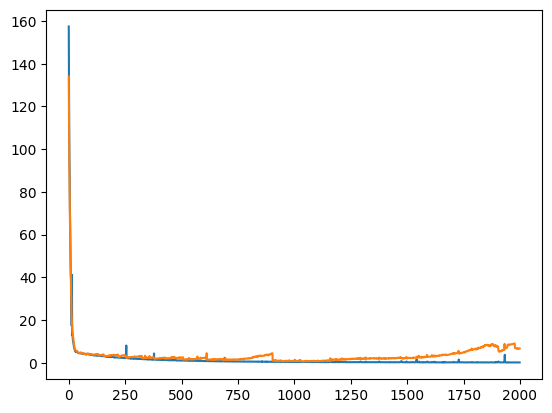

In [26]:
#all
plt.plot(train_losses)
plt.plot(val_losses)

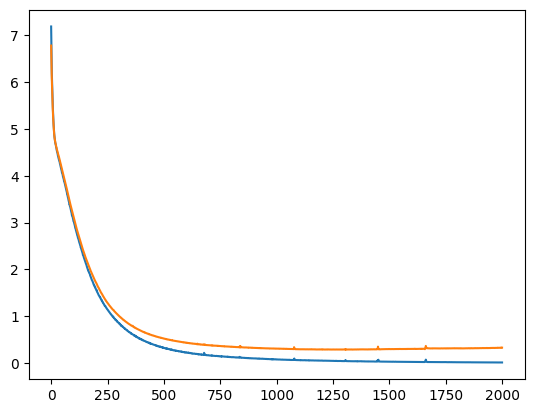

In [26]:
#real
plt.plot(train_losses)
plt.plot(val_losses)

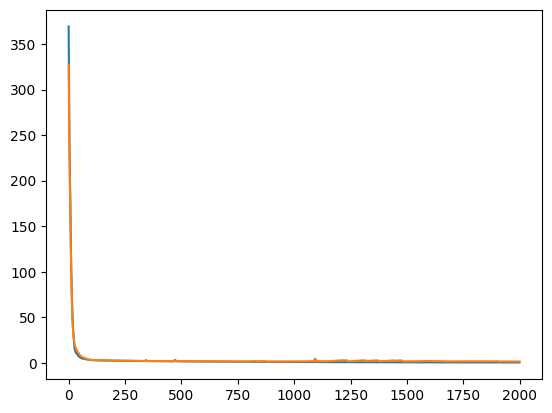

In [26]:
#simulated
plt.plot(train_losses)
plt.plot(val_losses)
#plt.ylim(0,20)

In [27]:
model.eval()
correct = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    outputs_class = nn.functional.softmax(outputs).argmax()
    labels_class = labels.argmax()
    correct += (outputs_class == labels_class)*1
acc = float(correct / len(test_loader))

/tmp/ipykernel_18288/3545108458.py:6: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  outputs_class = nn.functional.softmax(outputs).argmax()


In [28]:
acc

0.9114583134651184

In [29]:
#(29,50), (50, y.shape[1]), real, keep_sample_together=False, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.884
#(29,50), (50, y.shape[1]), simulated, keep_sample_together=False, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.561
#(29,50), (50,50), (50, y.shape[1]), real, keep_sample_together=False, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.878
#(29,50), (50,50), (50, y.shape[1]), simulated, keep_sample_together=False, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.667
#(29,50), (50,50), (50, y.shape[1]), real, keep_sample_together=True, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.887
#(29,50), Dropout, (50,50), (50, y.shape[1]), real, keep_sample_together=True, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.80
#(29,50), (50,50), (50, y.shape[1]), real, keep_sample_together=True, remove_outliers=False, 2000 epoch, lr=0.0001, Adam: acc=0.980
#(29,50), (50,50), (50, y.shape[1]), simulated, keep_sample_together=True, remove_outliers=False, 2000 epoch, lr=0.0001, Adam: acc=0.912

## Visualisation with confusion matrix

In [30]:
model.eval()
correct = 0
labels_saved = []
outputs_saved = []
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    outputs_class = nn.functional.softmax(outputs).argmax()
    outputs_saved.append(int(outputs_class))
    labels_class = labels.argmax()
    labels_saved.append(int(labels_class))
    correct += (outputs_class == labels_class)*1
acc = float(correct / len(test_loader))

/tmp/ipykernel_18288/1097759078.py:8: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  outputs_class = nn.functional.softmax(outputs).argmax()


In [31]:
import seaborn as sns

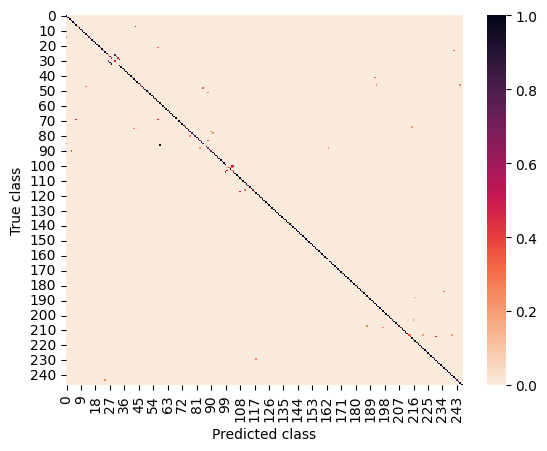

In [32]:
conf_mat = sklearn.metrics.confusion_matrix(labels_saved, outputs_saved, normalize='true')
sns.heatmap(conf_mat, cmap=sns.cm.rocket_r)
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.savefig('../results/visualisations/heatmap_'+real_or_simulated+'.png')

In [ ]:
#0.963 real
#0.846 simulated
#0.911 all